In [21]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make(
    "FrozenLake-v1",
    desc=[
        "FFSF",   # Starting state is in the first row
        "FFFF",
        "FFFF",
        "FGFF"    # Goal/ending state is in the last row
    ],
    is_slippery=True
)

state_size = env.observation_space.n
action_size = env.action_space.n

print("Number of states:", state_size)
print("Number of actions:", action_size)

Number of states: 16
Number of actions: 4


In [23]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05   # Minimum exploration rate
epsilon_decay = 0.9995

In [24]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((state_size, action_size))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Select an action using an epsilon-greedy strategy.
    """

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    return int(np.argmax(Q[state]))

In [25]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Select first action using epsilon-greedy policy
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        total_reward += reward

        # -------------------------------------------------
        # If episode is finished
        # -------------------------------------------------
        if done:

            target = reward

            Q[state, action] += alpha * (
                target - Q[state, action]
            )

            break

        # -------------------------------------------------
        # Select next action using current policy
        # -------------------------------------------------

        next_action = epsilon_greedy_action(
            next_state,
            epsilon
        )

        # -------------------------------------------------
        # SARSA Update
        # -------------------------------------------------

        target = reward + gamma * Q[next_state, next_action]

        Q[state, action] += alpha * (
            target - Q[state, action]
        )

        # Move to next state and action
        state = next_state
        action = next_action

    # Store episode reward
    episode_rewards.append(total_reward)

    # Reduce exploration gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# -------------------------------------------------
# Estimate State Values and Learned Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)

print("Training completed.")
print("Final epsilon:", round(epsilon, 4))

Training completed.
Final epsilon: 0.05


In [26]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


def print_policy(policy):

    # FrozenLake action mapping
    # 0 = Left
    # 1 = Down
    # 2 = Right
    # 3 = Up

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [27]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)

print_policy(learned_policy)

# Average reward over the last 1000 episodes
average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    average_reward
)


Final Q-table:
[[0.883 0.892 0.881 0.879]
 [0.89  0.881 0.878 0.876]
 [0.874 0.872 0.88  0.871]
 [0.858 0.879 0.861 0.849]
 [0.905 0.921 0.905 0.903]
 [0.917 0.905 0.904 0.892]
 [0.895 0.908 0.888 0.882]
 [0.886 0.898 0.887 0.874]
 [0.935 0.951 0.929 0.938]
 [0.93  0.943 0.936 0.916]
 [0.914 0.936 0.908 0.902]
 [0.903 0.917 0.896 0.903]
 [0.962 0.98  0.966 0.963]
 [0.    0.    0.    0.   ]
 [0.968 0.947 0.924 0.931]
 [0.918 0.935 0.909 0.914]]

Estimated State-Value Function:
[[0.892 0.89  0.88  0.879]
 [0.921 0.917 0.908 0.898]
 [0.951 0.943 0.936 0.917]
 [0.98  0.    0.968 0.935]]

Learned Policy:
[['D' 'L' 'R' 'D']
 ['D' 'L' 'D' 'D']
 ['D' 'D' 'D' 'D']
 ['D' 'L' 'L' 'D']]

Average reward over last 1000 episodes: 1.0


Name: Loknaath P
Register Number: 212223240080


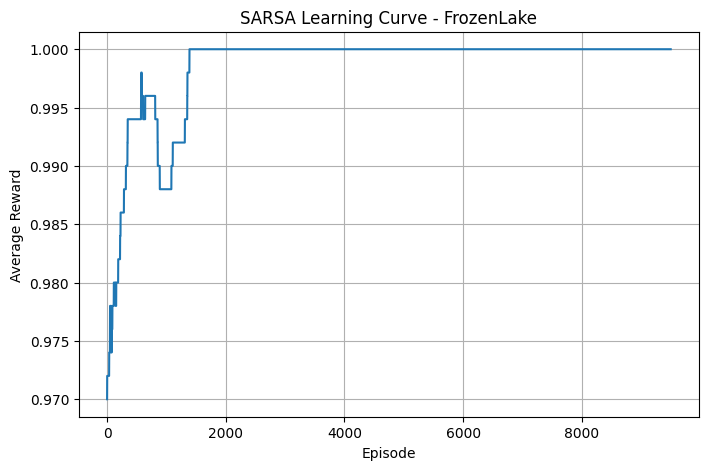

In [29]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------
print("Name: Loknaath P")
print("Register Number: 212223240080")

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()